📥 Loading MNIST dataset...
✅ Dataset ready! Training samples: 2000 Testing samples: 300

Training Naïve Bayes with m = 3 ...

====== My Naïve Bayes (m=3) ======
Accuracy: 0.73
F1-score: 0.7298
Confusion Matrix:
 [[22  0  0  1  0  1  0  0  0  1]
 [ 0 28  0  0  0  1  1  0  0  0]
 [ 0  1 20  1  1  3  0  1  0  0]
 [ 0  4  0 23  1  6  0  1  0  0]
 [ 1  0  0  0 25  0  0  0  0 14]
 [ 3  0  0  4  1 17  2  0  1  1]
 [ 0  1  0  0  0  0 32  0  1  0]
 [ 1  2  1  0  2  1  0 21  0  3]
 [ 0  1  0  3  1  2  0  1 17  5]
 [ 0  0  0  0  4  0  0  1  0 14]]

Training Naïve Bayes with m = 10 ...

====== My Naïve Bayes (m=10) ======
Accuracy: 0.75
F1-score: 0.7502
Confusion Matrix:
 [[22  0  0  1  0  1  0  0  0  1]
 [ 0 28  0  0  0  2  0  0  0  0]
 [ 0  1 21  1  0  2  1  1  0  0]
 [ 0  4  0 23  1  6  0  1  0  0]
 [ 1  0  0  0 26  0  0  0  0 13]
 [ 2  0  0  5  1 18  2  0  0  1]
 [ 0  1  0  0  0  0 32  0  1  0]
 [ 1  3  1  0  2  1  0 22  0  1]
 [ 0  1  0  3  1  2  0  1 17  5]
 [ 0  0  0  0  2  0  0  1  0 16]]


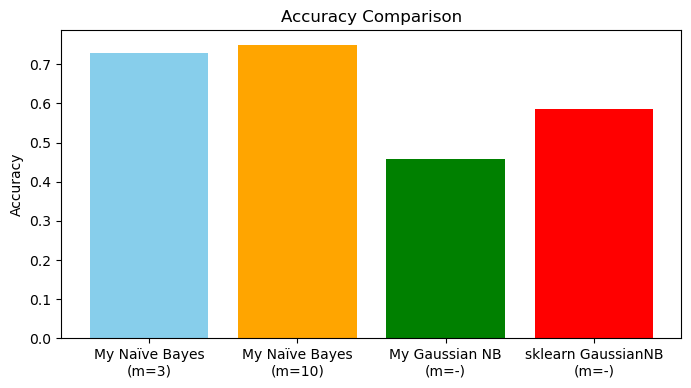

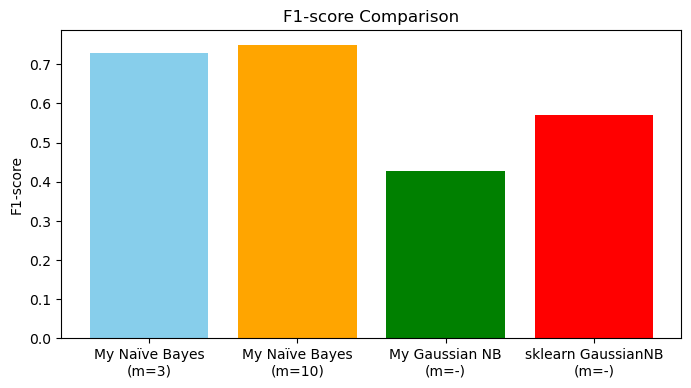


📊 Summary Results:
Model			m	Accuracy	F1-score
My Naïve Bayes      	3	0.7300		0.7298
My Naïve Bayes      	10	0.7500		0.7502
My Gaussian NB      	-	0.4567		0.4282
sklearn GaussianNB  	-	0.5867		0.5710


In [16]:
import numpy as np
from collections import Counter
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from math import log, pi, exp
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB

# ============================================================
# Task 1: Implement Naïve Bayesian Classifier (m-estimate)
# ============================================================

def Bayes_train(train_x, train_y, m=3):
    """
    Train Naïve Bayes with m-estimate smoothing.
    P(x|d) is estimated based on pixel intensity frequency.
    """
    num_classes = 10
    num_features = train_x.shape[1]
    totalNum = train_x.shape[0]
    classNum = Counter(train_y)
    
    # Prior probability P(d)
    prioriP = np.array([classNum[i] / totalNum for i in range(num_classes)])
    
    # Conditional probability P(x_i|d)
    posteriorP = np.zeros((num_classes, num_features, 256))
    
    for d in range(num_classes):
        class_samples = train_x[train_y == d]
        n_d = class_samples.shape[0]
        for j in range(num_features):
            counts = Counter(class_samples[:, j])
            for val in range(256):  # pixel values 0–255
                p = 1 / 256  # uniform prior
                posteriorP[d, j, val] = (counts.get(val, 0) + m * p) / (n_d + m)
    return prioriP, posteriorP


def Bayes_predict(test_x, prioriP, posteriorP):
    """
    Predict labels for test data using trained Naïve Bayes model.
    """
    preds = []
    for x in test_x:
        log_probs = []
        for d in range(10):
            logp = log(prioriP[d])
            for j, val in enumerate(x):
                logp += log(posteriorP[d, j, val])
            log_probs.append(logp)
        preds.append(np.argmax(log_probs))
    return np.array(preds)

# ============================================================
# Task 2: Implement Gaussian Naïve Bayes (Continuous likelihood)
# ============================================================

def Gaussian_train(train_x, train_y):
    """
    Train Gaussian Naïve Bayes assuming each pixel follows a Gaussian distribution.
    """
    num_classes = 10
    num_features = train_x.shape[1]
    mu = np.zeros((num_classes, num_features))
    sigma = np.zeros((num_classes, num_features))
    prioriP = np.zeros(num_classes)
    
    for d in range(num_classes):
        class_samples = train_x[train_y == d]
        mu[d] = np.mean(class_samples, axis=0)
        sigma[d] = np.std(class_samples, axis=0) + 1e-6
        prioriP[d] = class_samples.shape[0] / train_x.shape[0]
    return mu, sigma, prioriP


def Gaussian_predict(test_x, mu, sigma, prioriP):
    preds = []
    for x in test_x:
        log_probs = []
        for d in range(10):
            log_likelihood = -0.5 * np.sum(np.log(2 * pi * sigma[d]**2)) \
                             -0.5 * np.sum(((x - mu[d])**2) / (2 * sigma[d]**2))
            log_prob = np.log(prioriP[d]) + log_likelihood
            log_probs.append(log_prob)
        preds.append(np.argmax(log_probs))
    return np.array(preds)

# ============================================================
# Evaluation helper
# ============================================================

def evaluate(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"\n====== {model_name} ======")
    print("Accuracy:", round(acc, 4))
    print("F1-score:", round(f1, 4))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    return acc, f1

# ============================================================
# Main function
# ============================================================

def main():
    print("📥 Loading MNIST dataset...")
    X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.uint8)
    y = y.astype(np.int64)

    # To reduce computation, we use a smaller subset
    tr_feats = X[:2000]
    tr_label = y[:2000]
    te_feats = X[2000:2300]
    te_label = y[2000:2300]

    print("✅ Dataset ready! Training samples:", tr_feats.shape[0], "Testing samples:", te_feats.shape[0])

    # Task 1: m-estimate Naïve Bayes
    results = []
    for m in [3, 10]:
        print(f"\nTraining Naïve Bayes with m = {m} ...")
        prioriP, posteriorP = Bayes_train(tr_feats, tr_label, m=m)
        y_pred = Bayes_predict(te_feats, prioriP, posteriorP)
        acc, f1 = evaluate(te_label, y_pred, model_name=f"My Naïve Bayes (m={m})")
        results.append(("My Naïve Bayes", m, acc, f1))

    # Task 2: Gaussian Naïve Bayes
    print("\nTraining Gaussian Naïve Bayes ...")
    mu, sigma, prioriP = Gaussian_train(tr_feats, tr_label)
    y_pred_g = Gaussian_predict(te_feats, mu, sigma, prioriP)
    acc_g, f1_g = evaluate(te_label, y_pred_g, model_name="My Gaussian Naïve Bayes")
    results.append(("My Gaussian NB", "-", acc_g, f1_g))

    # Compare with sklearn GaussianNB
    print("\nTraining sklearn GaussianNB ...")
    nb = GaussianNB()
    nb.fit(tr_feats, tr_label)
    y_pred_sk = nb.predict(te_feats)
    acc_sk, f1_sk = evaluate(te_label, y_pred_sk, model_name="sklearn GaussianNB")
    results.append(("sklearn GaussianNB", "-", acc_sk, f1_sk))

    # Plot comparison
    methods = [f"{name}\n(m={m})" for name, m, _, _ in results]
    accs = [a for _, _, a, _ in results]
    f1s = [f for _, _, _, f in results]

    plt.figure(figsize=(8,4))
    plt.bar(methods, accs, color=['skyblue', 'orange', 'green', 'red'])
    plt.title("Accuracy Comparison")
    plt.ylabel("Accuracy")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.bar(methods, f1s, color=['skyblue', 'orange', 'green', 'red'])
    plt.title("F1-score Comparison")
    plt.ylabel("F1-score")
    plt.show()

    # Print summary
    print("\n📊 Summary Results:")
    print("Model\t\t\tm\tAccuracy\tF1-score")
    for name, m, acc, f1 in results:
        print(f"{name:20s}\t{m}\t{acc:.4f}\t\t{f1:.4f}")

if __name__ == "__main__":
    main()